# Cohesion-Sensitive Power Indices: Comprehensive Analysis & Figure Generation

This notebook implements the cohesion-sensitive power indices methodology and generates all figures for the paper. It includes:
- Core computational framework for cohesion-Shapley indices
- Analysis of an apex game example
- Application to German Bundestag 2025
- Application to French Assemblée Nationale 2024 (bloc and party models)

All computations use normalized cohesion-Shapley indices with ideology-based and cordon sanitaire cohesion functions.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations
import math
import warnings
warnings.filterwarnings('ignore')

# ── Modern academic style ─────────────────────────────────────────────
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linewidth': 0.4,
    'grid.linestyle': '-',
    'lines.linewidth': 1.3,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# ── Shared layout constants ───────────────────────────────────────────
# All multi-panel figures use the same panel height so fonts are
# identical size regardless of 2-panel vs 3-panel layout.
PANEL_H = 2.6   # inches per panel height
PANEL_W = 2.6   # inches per panel width
LW = 1.3        # line width

print("Style configured.")

Style configured.


In [2]:
def shapley_size_weight(k, n):
    """
    Compute Shapley size weight: k!(n-k-1)!/n!
    
    Args:
        k: size of coalition (integer)
        n: total number of players (integer)
    
    Returns:
        Shapley size weight (float)
    """
    if k < 0 or k >= n:
        return 0.0
    return math.factorial(k) * math.factorial(n - k - 1) / math.factorial(n)


def cohesion_shapley(players, weights, threshold, kappa_func, b_val):
    """
    Compute normalised Cohesion-Shapley index for a weighted majority game.

    Φ_i(v,κ,b) = Σ_{S⊆N\\{i}} ω_{|S|} · κ(S∪{i})^b · [v(S∪{i}) - v(S)]
                  ÷ Σ_{S⊆N\\{i}} ω_{|S|} · κ(S∪{i})^b

    where ω_k = k!(n-k-1)!/n! are the Shapley size weights,
    and the result is further normalised so Σ_i Φ_i = 1.

    Parameters
    ----------
    players : list of player labels
    weights : dict  player → seat count
    threshold : int  majority threshold (≥)
    kappa_func : callable  frozenset → float ∈ [0,1]
    b_val : float  cohesion exponent (> 0)

    Returns
    -------
    dict  {player: normalised power index}
    """
    n = len(players)
    others_of = {p: [q for q in players if q != p] for p in players}

    raw_phi = {}
    for i in players:
        others = others_of[i]
        m = len(others)
        numerator = 0.0
        denominator = 0.0
        for r in range(m + 1):
            omega_r = shapley_size_weight(r, n)
            for combo in combinations(others, r):
                S = frozenset(combo)
                S_plus_i = S | {i}
                kap = kappa_func(S_plus_i)
                kap_b = kap ** b_val if kap > 0 else 0.0
                term = omega_r * kap_b
                denominator += term
                # pivotality check
                w_S = sum(weights[p] for p in S)
                if (w_S + weights[i] >= threshold) and (w_S < threshold):
                    numerator += term
        raw_phi[i] = numerator / denominator if denominator > 0 else 0.0

    # normalise so values sum to 1
    total = sum(raw_phi.values())
    if total > 0:
        return {p: raw_phi[p] / total for p in players}
    else:
        return {p: 0.0 for p in players}


print("Core functions loaded successfully.")

Core functions loaded successfully.


## 1. Three-Player Majority Game (Figure 1)

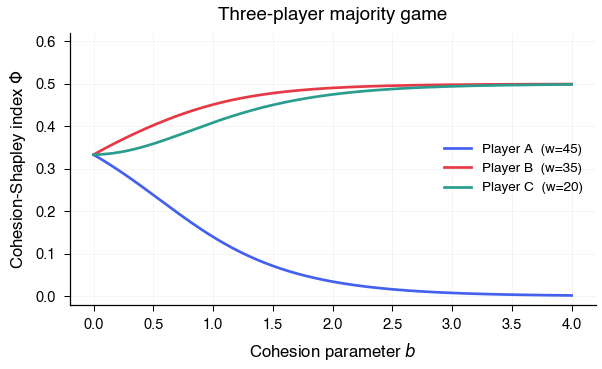

At b=1: A=0.1390, B=0.4517, C=0.4094


In [4]:
# Three-player majority game setup
apex_players = ['A', 'B', 'C']
apex_weights = {'A': 45, 'B': 35, 'C': 20}
apex_threshold = 51

apex_cohesion_values = {
    frozenset(['A', 'B']): 0.20,
    frozenset(['A', 'C']): 0.05,
    frozenset(['B', 'C']): 0.90,
    frozenset(['A', 'B', 'C']): 0.05
}

def apex_kappa(coalition):
    key = frozenset(coalition)
    return apex_cohesion_values.get(key, 1.0)

b_values_apex = np.linspace(0.001, 4.0, 300)
apex_results = {p: [] for p in apex_players}

for b in b_values_apex:
    indices = cohesion_shapley(apex_players, apex_weights, apex_threshold, apex_kappa, b)
    for p in apex_players:
        apex_results[p].append(indices[p])

# ── Figure 1 ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(PANEL_W * 1.6, PANEL_H))

palette = {'A': '#4361ee', 'B': '#e63946', 'C': '#2a9d8f'}

for p in apex_players:
    ax.plot(b_values_apex, apex_results[p],
            label=f'Player {p}  (w={apex_weights[p]})',
            color=palette[p], linewidth=LW)

ax.set_xlabel(r'Cohesion parameter $b$')
ax.set_ylabel(r'Cohesion-Shapley index $\Phi$')
ax.set_title('Three-player majority game')
ax.set_ylim(-0.02, 0.62)
ax.legend(frameon=False, loc='center right')

fig.tight_layout()
#fig.savefig('fig1_apex.pdf', dpi=300, bbox_inches='tight')
fig.savefig('fig1_apex.png', dpi=600, bbox_inches='tight')
plt.show()

idx1 = np.argmin(np.abs(b_values_apex - 1.0))
print(f"At b=1: A={apex_results['A'][idx1]:.4f}, "
      f"B={apex_results['B'][idx1]:.4f}, C={apex_results['C'][idx1]:.4f}")

## 2. Germany: 21st Bundestag 2025 (Figure 2)

CHES 2019 raw (Germany):
            party     lrgen
party_id                   
301           CDU  5.857143
302           SPD  3.619048
303           FDP  6.428571
304        GRUNEN  3.238095
306         LINKE  1.428572
308           CSU  7.190476
310           AfD  9.238095
311       Piraten  2.142857
312       DieTier  2.333333

Bundestag 2025 seats:
party  seats
  CDU    164
  CSU     44
  SPD    120
Grüne     85
  AfD    152
Linke     64
  SSW      1

Analysis groups (629 seats, threshold 316):
  CDU/CSU   : 208 seats, lrgen = 6.1392
  SPD       : 120 seats, lrgen = 3.6190
  Grüne     :  85 seats, lrgen = 3.2381
  AfD       : 152 seats, lrgen = 9.2381
  Linke     :  64 seats, lrgen = 1.4286


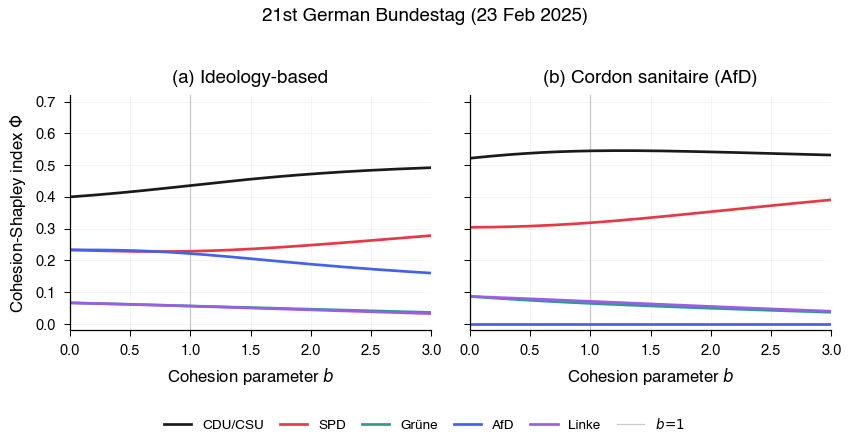

Scenario A at b=1: CDU/CSU=0.436, SPD=0.229, Grüne=0.057, AfD=0.222, Linke=0.057  (Σ=1.000)
Scenario B at b=1: CDU/CSU=0.545, SPD=0.319, Grüne=0.065, AfD=0.000, Linke=0.071  (Σ=1.000)


In [29]:
# ── Load raw data ──────────────────────────────────────────────────────
ches = pd.read_csv('../data/CHES2019V3.csv')

ches_de = ches[ches['country'] == 3][['party', 'party_id', 'lrgen']].set_index('party_id')
bt_seats = pd.read_csv('../data/bundestag_2025.csv')

print("CHES 2019 raw (Germany):")
print(ches_de.to_string())
print(f"\nBundestag 2025 seats:")
print(bt_seats[['party', 'seats']].to_string(index=False))

# ── Build analysis groups ─────────────────────────────────────────────
cdu_lrgen = ches_de.loc[301, 'lrgen']
csu_lrgen = ches_de.loc[308, 'lrgen']
cdu_seats = bt_seats.loc[bt_seats['party'] == 'CDU', 'seats'].values[0]
csu_seats = bt_seats.loc[bt_seats['party'] == 'CSU', 'seats'].values[0]
cdu_csu_ches = (cdu_lrgen * cdu_seats + csu_lrgen * csu_seats) / (cdu_seats + csu_seats)

ches_map_de = {'SPD': 302, 'Grüne': 304, 'AfD': 310, 'Linke': 306}
bt_groups = {'CDU/CSU': {'seats': int(cdu_seats + csu_seats), 'ches': round(cdu_csu_ches, 4)}}
for party, ches_id in ches_map_de.items():
    seats = int(bt_seats.loc[bt_seats['party'] == party, 'seats'].values[0])
    bt_groups[party] = {'seats': seats, 'ches': round(ches_de.loc[ches_id, 'lrgen'], 4)}

print(f"\nAnalysis groups ({sum(g['seats'] for g in bt_groups.values())} seats, threshold 316):")
for name, g in bt_groups.items():
    print(f"  {name:10s}: {g['seats']:3d} seats, lrgen = {g['ches']:.4f}")

# ── Computation ───────────────────────────────────────────────────────
bt_players = list(bt_groups.keys())
bt_weights = {p: bt_groups[p]['seats'] for p in bt_players}
bt_ches    = {p: bt_groups[p]['ches']  for p in bt_players}
bt_threshold = 316

def bt_kappa_ideology(S):
    if len(S) <= 1: return 1.0
    pos = [bt_ches[p] for p in S]
    return 1.0 / (1.0 + max(pos) - min(pos))

def bt_kappa_cordon(S):
    if 'AfD' in S: return 0.0
    return bt_kappa_ideology(S)

b_values_bt = np.linspace(0.001, 3.0, 200)
bt_A = {p: [] for p in bt_players}
bt_B = {p: [] for p in bt_players}

for b in b_values_bt:
    phi_A = cohesion_shapley(bt_players, bt_weights, bt_threshold, bt_kappa_ideology, b)
    phi_B = cohesion_shapley(bt_players, bt_weights, bt_threshold, bt_kappa_cordon,   b)
    for p in bt_players:
        bt_A[p].append(phi_A[p])
        bt_B[p].append(phi_B[p])

# ── Figure 2: two panels, same PANEL_H as the 3-panel France plots ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(PANEL_W * 2 + 0.6, PANEL_H), sharey=True)

colors_bt = {
    'CDU/CSU': '#1a1a1a',
    'SPD':     '#e63946',
    'Grüne':   '#2a9d8f',
    'AfD':     '#4361ee',
    'Linke':   '#9b5de5',
}

for ax, data, title in [(ax1, bt_A, '(a) Ideology-based'),
                         (ax2, bt_B, '(b) Cordon sanitaire (AfD)')]:
    for p in bt_players:
        ax.plot(b_values_bt, data[p], color=colors_bt[p], linewidth=LW, label=p)
    ax.axvline(x=1, color='#cccccc', linewidth=0.6, zorder=0)
    ax.set_xlabel(r'Cohesion parameter $b$')
    ax.set_title(title)
    ax.set_xlim(0, 3)

ax1.set_ylabel(r'Cohesion-Shapley index $\Phi$')
ax1.set_ylim(-0.02, 0.72)

# Shared legend below
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=colors_bt[p], lw=LW) for p in bt_players]
handles.append(Line2D([0], [0], color='#cccccc', lw=0.6))
labels  = list(bt_players) + [r'$b\!=\!1$']
fig.legend(handles, labels, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.10), frameon=False, columnspacing=1.2)
fig.suptitle('21st German Bundestag (23 Feb 2025)',
             fontsize=9, y=1.02, fontstyle='italic', fontweight='normal')
fig.tight_layout()
#fig.savefig('fig2_bundestag.pdf', bbox_inches='tight')
fig.savefig('fig2_bundestag.png', dpi=500, bbox_inches='tight')
plt.show()

idx1 = np.argmin(np.abs(b_values_bt - 1.0))
for tag, d in [('A', bt_A), ('B', bt_B)]:
    vals = {p: d[p][idx1] for p in bt_players}
    print(f"Scenario {tag} at b=1: " +
          ", ".join(f"{p}={v:.3f}" for p, v in vals.items()) +
          f"  (Σ={sum(vals.values()):.3f})")

## 3. France: 17th Assemblée Nationale 2024

In [23]:
# ── Load raw data ──────────────────────────────────────────────────────
# CHES already loaded above; France = country 6
ches_fr = ches[ches['country'] == 6][['party', 'party_id', 'lrgen']].set_index('party_id')
fr_raw = pd.read_csv('../data/france_2024.csv')

print("CHES 2019 raw (France):")
print(ches_fr.to_string())
print(f"\nFrance 2024 seats:")
print(fr_raw[['party', 'bloc', 'seats']].to_string(index=False))

# ── Helper: seat-weighted average of lrgen within a bloc ─────────────
def bloc_weighted_lrgen(df, bloc_name):
    """Compute seat-weighted lrgen for a bloc using the CSV data."""
    rows = df[df['bloc'] == bloc_name]
    return (rows['ches_lrgen'] * rows['seats']).sum() / rows['seats'].sum()

# ── BLOC MODEL (5 groups) ────────────────────────────────────────────
# All values come from the CSV; approximations are stored there with
# rationale in the ches_source column.
bloc_order = ['NFP', 'Ensemble', 'LR', 'RN', 'Other']
fr_bloc_groups = {}
for bloc in bloc_order:
    rows = fr_raw[fr_raw['bloc'] == bloc]
    seats = int(rows['seats'].sum())
    lrgen = bloc_weighted_lrgen(fr_raw, bloc)
    fr_bloc_groups[bloc] = {'seats': seats, 'ches': round(lrgen, 4)}

# Rename 'Other' → 'Others' for display consistency
fr_bloc_groups['Others'] = fr_bloc_groups.pop('Other')

# ── PARTY MODEL (6 groups) ───────────────────────────────────────────
# LFI standalone
lfi_row = fr_raw[fr_raw['party'] == 'LFI']
lfi_lrgen = float(lfi_row['ches_lrgen'].values[0])
lfi_seats = int(lfi_row['seats'].values[0])

# PS-Verts: PS + Écologistes + GDR/PCF (NFP minus LFI)
psv_parties = ['PS', 'Écologistes', 'GDR/PCF']
psv_rows = fr_raw[fr_raw['party'].isin(psv_parties)]
psv_seats = int(psv_rows['seats'].sum())
psv_lrgen = (psv_rows['ches_lrgen'] * psv_rows['seats']).sum() / psv_rows['seats'].sum()

# Ensemble, LR, RN, Others — reuse bloc-level aggregates
fr_party_groups = {
    'LFI':      {'seats': lfi_seats,                      'ches': round(lfi_lrgen, 4)},
    'PS-Verts': {'seats': psv_seats,                      'ches': round(psv_lrgen, 4)},
    'Ensemble': fr_bloc_groups['Ensemble'],
    'LR':       fr_bloc_groups['LR'],
    'RN':       fr_bloc_groups['RN'],
    'Others':   fr_bloc_groups['Others'],
}

fr_threshold = 289  # > half of 577

print(f"\nBloc model (total = {sum(g['seats'] for g in fr_bloc_groups.values())} seats):")
for name, g in fr_bloc_groups.items():
    print(f"  {name:10s}: {g['seats']:3d} seats, CHES lrgen = {g['ches']:.4f}")

print(f"\nParty model (total = {sum(g['seats'] for g in fr_party_groups.values())} seats):")
for name, g in fr_party_groups.items():
    print(f"  {name:10s}: {g['seats']:3d} seats, CHES lrgen = {g['ches']:.4f}")

# ── Cohesion functions ────────────────────────────────────────────────
def make_kappa_ideology(ches_dict):
    def kappa(coalition):
        if len(coalition) <= 1:
            return 1.0
        positions = [ches_dict[p] for p in coalition]
        return 1.0 / (1.0 + max(positions) - min(positions))
    return kappa

print("\nFrance data loaded and prepared.")

CHES 2019 raw (France):
          party     lrgen
party_id                 
601         PCF  1.125000
602          PS  3.000000
605        EELV  2.500000
609          LR  7.875000
610          RN  9.750000
613       MoDem  6.125000
626        LREM  6.333334
627          FI  1.250000
628         DLF  9.000000

France 2024 seats:
       party     bloc  seats
         LFI      NFP     71
          PS      NFP     69
 Écologistes      NFP     38
     GDR/PCF      NFP     17
 Renaissance Ensemble     92
       MoDem Ensemble     36
    Horizons Ensemble     34
          LR       LR     49
          RN       RN    122
  UDR/Ciotti       RN     17
        LIOT    Other     22
Non-inscrits    Other     10

Bloc model (total = 577 seats):
  NFP       : 195 seats, CHES lrgen = 2.1024
  Ensemble  : 162 seats, CHES lrgen = 6.2583
  LR        :  49 seats, CHES lrgen = 7.8800
  RN        : 139 seats, CHES lrgen = 9.5971
  Others    :  32 seats, CHES lrgen = 5.0000

Party model (total = 577 seats):
 

In [24]:
# ── BLOC MODEL computation ────────────────────────────────────────────
fr_bloc_players = list(fr_bloc_groups.keys())
fr_bloc_weights = {p: fr_bloc_groups[p]['seats'] for p in fr_bloc_players}
fr_bloc_ches = {p: fr_bloc_groups[p]['ches'] for p in fr_bloc_players}

kappa_bloc_ideo = make_kappa_ideology(fr_bloc_ches)

def fr_bloc_kappa_B(coalition):
    """Cordon sanitaire vs RN."""
    if 'RN' in coalition:
        return 0.0
    return kappa_bloc_ideo(coalition)

def fr_bloc_kappa_C(coalition):
    """Double cordon: vs RN and NFP."""
    if 'RN' in coalition or 'NFP' in coalition:
        return 0.0
    return kappa_bloc_ideo(coalition)

b_values_fr = np.linspace(0.001, 3.0, 200)
fr_bloc_results_A = {p: [] for p in fr_bloc_players}
fr_bloc_results_B = {p: [] for p in fr_bloc_players}
fr_bloc_results_C = {p: [] for p in fr_bloc_players}

for b in b_values_fr:
    phi_A = cohesion_shapley(fr_bloc_players, fr_bloc_weights, fr_threshold, kappa_bloc_ideo, b)
    phi_B = cohesion_shapley(fr_bloc_players, fr_bloc_weights, fr_threshold, fr_bloc_kappa_B, b)
    phi_C = cohesion_shapley(fr_bloc_players, fr_bloc_weights, fr_threshold, fr_bloc_kappa_C, b)
    for p in fr_bloc_players:
        fr_bloc_results_A[p].append(phi_A[p])
        fr_bloc_results_B[p].append(phi_B[p])
        fr_bloc_results_C[p].append(phi_C[p])

print("Bloc model computation complete.")

Bloc model computation complete.


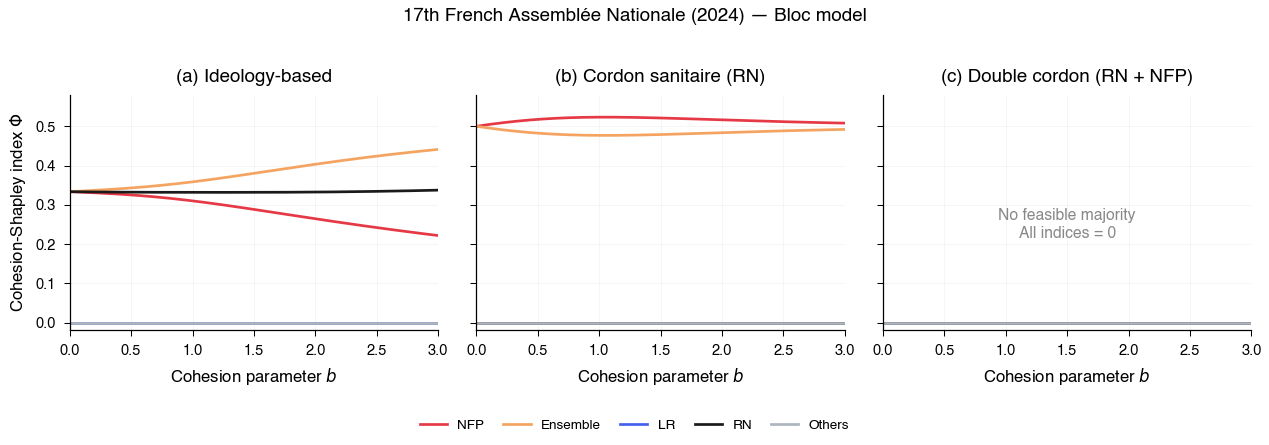

Scenario A: NFP=0.310, Ensemble=0.358, LR=0.000, RN=0.332, Others=0.000  (Σ=1.000)
Scenario B: NFP=0.523, Ensemble=0.477, LR=0.000, RN=0.000, Others=0.000  (Σ=1.000)
Scenario C: NFP=0.000, Ensemble=0.000, LR=0.000, RN=0.000, Others=0.000  (Σ=0.000)


In [30]:
# ── Figure 3: France Bloc Model (3 panels, same PANEL_H) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(PANEL_W * 3 + 0.8, PANEL_H), sharey=True)

colors_fr = {
    'NFP':      '#e63946',
    'Ensemble': '#f4a460',
    'LR':       '#4361ee',
    'RN':       '#1a1a1a',
    'Others':   '#adb5bd',
}

titles = ['(a) Ideology-based',
          '(b) Cordon sanitaire (RN)',
          '(c) Double cordon (RN + NFP)']
datasets = [fr_bloc_results_A, fr_bloc_results_B, fr_bloc_results_C]

for ax, data, title in zip(axes, datasets, titles):
    for p in fr_bloc_players:
        ax.plot(b_values_fr, data[p], color=colors_fr[p], linewidth=LW, label=p)
    ax.set_xlabel(r'Cohesion parameter $b$')
    ax.set_title(title)
    ax.set_xlim(0, 3)

axes[0].set_ylabel(r'Cohesion-Shapley index $\Phi$')
axes[0].set_ylim(-0.02, 0.58)

# Annotation on the empty panel
axes[2].text(1.5, 0.25, 'No feasible majority\nAll indices = 0',
             ha='center', va='center', fontsize=7.5,
             fontstyle='italic', color='#888888')

# Shared legend below
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=colors_fr[p], lw=LW) for p in fr_bloc_players]
labels  = list(fr_bloc_players)
fig.legend(handles, labels, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.10), frameon=False, columnspacing=1.4)
fig.suptitle('17th French Assemblée Nationale (2024) — Bloc model',
             fontsize=9, y=1.02, fontstyle='italic', fontweight='normal')
fig.tight_layout()
#fig.savefig('fig3_france_bloc.pdf', bbox_inches='tight')
fig.savefig('fig3_france_bloc.png', dpi=500, bbox_inches='tight')
plt.show()

idx1 = np.argmin(np.abs(b_values_fr - 1.0))
for tag, data in [('A', fr_bloc_results_A), ('B', fr_bloc_results_B), ('C', fr_bloc_results_C)]:
    vals = {p: data[p][idx1] for p in fr_bloc_players}
    print(f"Scenario {tag}: " + ", ".join(f"{p}={v:.3f}" for p, v in vals.items()) +
          f"  (Σ={sum(vals.values()):.3f})")

In [26]:
# ── PARTY MODEL computation ───────────────────────────────────────────
fr_party_players = list(fr_party_groups.keys())
fr_party_weights = {p: fr_party_groups[p]['seats'] for p in fr_party_players}
fr_party_ches = {p: fr_party_groups[p]['ches'] for p in fr_party_players}

kappa_party_ideo = make_kappa_ideology(fr_party_ches)

def fr_party_kappa_B(coalition):
    """Cordon sanitaire vs RN."""
    if 'RN' in coalition:
        return 0.0
    return kappa_party_ideo(coalition)

def fr_party_kappa_C(coalition):
    """Double cordon: vs RN and LFI."""
    if 'RN' in coalition or 'LFI' in coalition:
        return 0.0
    return kappa_party_ideo(coalition)

fr_party_results_A = {p: [] for p in fr_party_players}
fr_party_results_B = {p: [] for p in fr_party_players}
fr_party_results_C = {p: [] for p in fr_party_players}

for b in b_values_fr:
    phi_A = cohesion_shapley(fr_party_players, fr_party_weights, fr_threshold, kappa_party_ideo, b)
    phi_B = cohesion_shapley(fr_party_players, fr_party_weights, fr_threshold, fr_party_kappa_B, b)
    phi_C = cohesion_shapley(fr_party_players, fr_party_weights, fr_threshold, fr_party_kappa_C, b)
    for p in fr_party_players:
        fr_party_results_A[p].append(phi_A[p])
        fr_party_results_B[p].append(phi_B[p])
        fr_party_results_C[p].append(phi_C[p])

print("Party model computation complete.")

Party model computation complete.


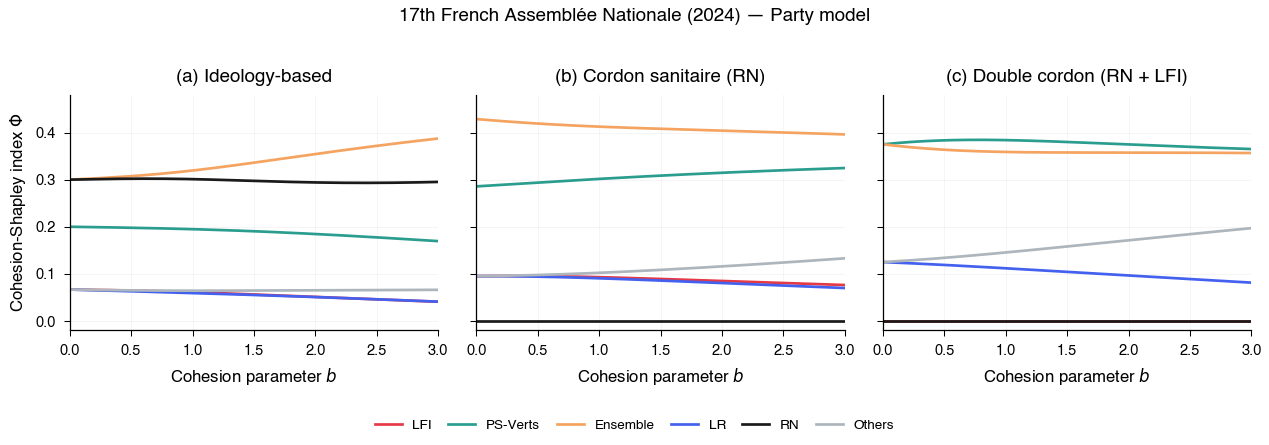

Scenario A: LFI=0.061, PS-Verts=0.195, Ensemble=0.319, LR=0.059, RN=0.301, Others=0.064  (Σ=1.000)
Scenario B: LFI=0.093, PS-Verts=0.302, Ensemble=0.413, LR=0.091, RN=0.000, Others=0.102  (Σ=1.000)
Scenario C: LFI=0.000, PS-Verts=0.384, Ensemble=0.359, LR=0.112, RN=0.000, Others=0.145  (Σ=1.000)


In [31]:
# ── Figure 4: France Party Model (3 panels, same PANEL_H) ────────────
fig, axes = plt.subplots(1, 3, figsize=(PANEL_W * 3 + 0.8, PANEL_H), sharey=True)

colors_party = {
    'LFI':      '#e63946',
    'PS-Verts': '#2a9d8f',
    'Ensemble': '#f4a460',
    'LR':       '#4361ee',
    'RN':       '#1a1a1a',
    'Others':   '#adb5bd',
}

titles = ['(a) Ideology-based',
          '(b) Cordon sanitaire (RN)',
          '(c) Double cordon (RN + LFI)']
datasets = [fr_party_results_A, fr_party_results_B, fr_party_results_C]

for ax, data, title in zip(axes, datasets, titles):
    for p in fr_party_players:
        ax.plot(b_values_fr, data[p], color=colors_party[p], linewidth=LW, label=p)
    ax.set_xlabel(r'Cohesion parameter $b$')
    ax.set_title(title)
    ax.set_xlim(0, 3)

axes[0].set_ylabel(r'Cohesion-Shapley index $\Phi$')
axes[0].set_ylim(-0.02, 0.48)

# Shared legend below
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=colors_party[p], lw=LW) for p in fr_party_players]
labels  = list(fr_party_players)
fig.legend(handles, labels, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.10), frameon=False, columnspacing=1.2)
fig.suptitle('17th French Assemblée Nationale (2024) — Party model',
             fontsize=9, y=1.02, fontstyle='italic', fontweight='normal')
fig.tight_layout()
#fig.savefig('fig4_france_party.pdf', bbox_inches='tight')
fig.savefig('fig4_france_party.png', dpi=500, bbox_inches='tight')
plt.show()

idx1 = np.argmin(np.abs(b_values_fr - 1.0))
for tag, data in [('A', fr_party_results_A), ('B', fr_party_results_B), ('C', fr_party_results_C)]:
    vals = {p: data[p][idx1] for p in fr_party_players}
    print(f"Scenario {tag}: " + ", ".join(f"{p}={v:.3f}" for p, v in vals.items()) +
          f"  (Σ={sum(vals.values()):.3f})")